In [2]:
import dadi, numpy as np, matplotlib.pyplot as plt, demes, demesdraw, pysam, pathlib, random, json, datetime

def split_mig_model(params, ns, pts):
    import dadi
    nu_AFR, nu_EUR, T, m = params

    xx  = dadi.Numerics.default_grid(pts)
    phi = dadi.PhiManip.phi_1D(xx)
    phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

    # Single epoch from split to present, with symmetric migration
    phi = dadi.Integration.two_pops(
        phi, xx, T,
        nu1=nu_AFR, nu2=nu_EUR,
        m12=m, m21=m
    )

    return dadi.Spectrum.from_phi(phi, ns, (xx, xx), mask_corners=False)
    # ────────────────────────────────────────────────────────────────
    return fs

In [4]:
import pathlib
import pysam
import dadi

# ── User inputs ──────────────────────────────────────────────────────
VCF = pathlib.Path(
    "/proj/johrilab/projects/ghist_2025/intermediate_files/austins_bmap/"
    "B.85_GHIST_2025_split.testing.noNonsyn.vcf"
)

#VCF = pathlib.Path(
#    "/proj/johrilab/projects/ghist_2025/intermediate_files/austins_bmap/"
#    "B.85_GHIST_2025_split.final.noNonsyn.vcf"
#)

#VCF = pathlib.Path(
#    "/nas/longleaf/home/adaigle/users/ghist_2025/test_sims/"
#    "split_recontact/replicate_2.nuc.withAA.vcf"
#)

#REGION_LENGTH = 21_675_000 - 4_750  # total callable bases (after B value filtering and - nonsynonomous sites (which i removed after I calculated l))
#for final 
REGION_LENGTH = 21_675_000 - 4438  # total callable bases (after B value filtering and - nonsynonomous sites (which i removed after I calculated l))

pop_ids       = ["AFR", "EUR"]
ns            = [24, 46]     # number of chromosomes

# ── 1) make a .popfile.txt if needed ────────────────────────────────
popfile = VCF.with_suffix(".popfile.txt")
if not popfile.exists():
    with popfile.open("w") as fh:
        for sample in pysam.VariantFile(str(VCF)).header.samples:
            pop = sample.split("_", 1)[0]
            fh.write(f"{sample}\t{pop}\n")

# ── 2) build data-dict & raw SFS (unmasked corners) ─────────────────
dd = dadi.Misc.make_data_dict_vcf(str(VCF), str(popfile))
fs = dadi.Spectrum.from_data_dict(
    dd, pop_ids, ns,
    polarized=True,       # or False if you want folded
    mask_corners=False,   # allow corner bins to be unmasked
)

# ── 3) inject monomorphic sites into [0,0] ─────────────────────────
observed_sites = fs.sum()
mono = REGION_LENGTH - observed_sites
fs[0, 0] += mono

# ── 4) explicitly unmask the corners you care about ────────────────
fs.mask[0, 0]   = True   # invariant
fs.mask[-1, -1] = True   # fixed-derived
fs.mask[0, -1]  = True  # private-derived on EUR
fs.mask[-1, 0]  = True  # private-derived on AFR

# ── 5) sanity checks ────────────────────────────────────────────────
print("Total sites in fs:", fs.sum(), "(should equal number of sites in vcf)")
print(fs)


Total sites in fs: 83644.0 (should equal number of sites in vcf)
[[-- 16329.0 6437.0 ... 0.0 0.0 --]
 [9931.0 846.0 572.0 ... 0.0 0.0 0.0]
 [3393.0 486.0 366.0 ... 0.0 0.0 0.0]
 ...
 [0.0 0.0 0.0 ... 30.0 34.0 52.0]
 [0.0 0.0 0.0 ... 26.0 40.0 72.0]
 [-- 0.0 0.0 ... 98.0 111.0 --]]


In [3]:
print(f"Shared fixed = {fs[-1,-1]}, Private fixed = {fs[-1,0] + fs[0,-1]}, Monomorphic = {fs[0,0]}")

NameError: name 'fs' is not defined

In [11]:
#make sure 0,0 is unmasked when you save this!

out_file = "/nas/longleaf/home/adaigle/johri/projects/ghist_2025/intermediate_files/GHIST2025_splitbgs_testing_jointSFS.obs"
#out_file = "/nas/longleaf/home/adaigle/johri/projects/ghist_2025/intermediate_files/GHIST2025_splitbgs_final_jointSFS.obs"

# 0) Make absolutely sure no bins are masked
fs.mask[:] = False

# 1) Grab the integer matrix
mat = fs.data.astype(int)

# 2) Write out for fastsimcoal2
n0, n1 = ns

with open(out_file, "w") as fh:
    fh.write("1 observations\n")
    fh.write(" ".join(f"d0_{j}" for j in range(n0+1)) + "\n")
    for i in range(n1+1):
        counts = [str(mat[j, i]) for j in range(n0+1)]
        fh.write(" ".join([f"d1_{i}"] + counts) + "\n")

print(f"Wrote 2D‐SFS for fastsimcoal2 to {out_file}")



Wrote 2D‐SFS for fastsimcoal2 to /nas/longleaf/home/adaigle/johri/projects/ghist_2025/intermediate_files/GHIST2025_splitbgs_testing_jointSFS.obs


In [ ]:
# ── 1) FSC2 estimates ─────────────────────────────────────────────────
Ncurr1   = 288_739.0    # pop 1 current size
Ncurr2   = 596_064.0    # pop 2 current size
Tcontact = 15_402.0     # generations since secondary contact
Tsplit   = 96_652.0     # generations since split
Nanc     = 290_300.0    # ancestral size
m12_fsc  = 1.20221e-05  # per‐gen. rate into pop1
m21_fsc  = 1.27395e-05  # per‐gen. rate into pop2

# ── 2) Convert to Dadi “nu”’s and times (in 2Nref units) ───────────────
nu1   = Ncurr1 / Nanc
nu2   = Ncurr2 / Nanc

T_tot = Tsplit   / (2 * Nanc)     # split time in coalescent units
T_mig = Tcontact / (2 * Nanc)     # secondary‐contact time in same units

# ── 3) Convert per‐gen m’s to Dadi’s scaled m = 2*Nref*m_fsc (we’ll average)
m_scaled = 2 * Nanc * (m12_fsc + m21_fsc) / 2

# ── 4) Pack into your Dadi initial‐guess vector ────────────────────────
p0 = [nu1, nu2, T_tot, T_mig, m_scaled]

print("Dadi initial p0:", p0)


In [ ]:
from scipy.optimize import differential_evolution

# Define the sample sizes
ns = fs.sample_sizes

# Grid points for numerical integration
pts_l = [50, 60, 70]

# Initial parameter guesses: (nu_AFR, nu_EUR, T_split, m)
p0 = [1.0, 1.0, 1, 0.1]  

# Bounds for parameters
lower = [1e-3, 1e-3, 1e-4, 0.0]
upper = [  100,   100,   10.0, 10.0]
# Generate the model SFS
func = dadi.Numerics.make_extrap_log_func(split_mig_model)

initial_guesses = [
    [1.0, 1.0, 0.5, 0.1],
    [2.0, 0.5, 1.0, 0.05],
    [0.5, 2.0, 0.2, 0.5],
    [1.5, 1.5, 0.1, 0.01],
]

best_popt = None
best_ll = -float("inf")

for p0 in initial_guesses:
    try:
        popt = dadi.Inference.optimize_log(
            p0, fs, func, pts_l, lower_bound=lower, upper_bound=upper
        )
        model = func(popt, ns, pts_l)
        ll_model = dadi.Inference.ll_multinom(model, fs)
        if ll_model > best_ll:
            best_ll = ll_model
            best_popt = popt
        print(f"Log-likelihood for initial guess {p0}: {ll_model}")
    except ValueError as e:
        print("Error during optimization:", e)

print("Best parameters after multiple initializations:", best_popt)

popt=best_popt

Log-likelihood for initial guess [1.0, 1.0, 0.5, 0.1]: -3323.422136621125
Log-likelihood for initial guess [2.0, 0.5, 1.0, 0.05]: -3473.8052746957464
Log-likelihood for initial guess [0.5, 2.0, 0.2, 0.5]: -3323.421576265385
Log-likelihood for initial guess [1.5, 1.5, 0.1, 0.01]: -3323.430771717325
Best parameters after multiple initializations: [1.00464772 1.56161443 0.13657085 0.79814265]


In [27]:
# you can furthur refine the params with DE and DA, doesn't change much
import numpy as np
from scipy.optimize import differential_evolution, dual_annealing

# 1) Grab your current best‐guess
p0 = np.array(best_popt)

# 2) Build a ±50% search window around it (tweak `frac` if you’d like tighter)
frac = 0.5
lower = p0 * (1 - frac)
upper = p0 * (1 + frac)
# make sure nothing is ≤ 0
lower = np.maximum(lower, 1e-8)
upper = np.maximum(upper, lower + 1e-8)

bounds = list(zip(lower, upper))

# 3) Define our negative‐log‐likelihood objective
def obj(params):
    model = func(params, ns, pts_l)
    return -dadi.Inference.ll_multinom(model, fs)

# 4) Quick local Differential Evolution
de_res = differential_evolution(
    obj,
    bounds,
    maxiter=200,
    popsize=10,
    polish=False  # we’ll polish below
)
print("DE refined x:", de_res.x, "LL =", -de_res.fun)

# 5) Quick local Dual Annealing
da_res = dual_annealing(
    obj,
    bounds,
    maxiter=500,
    visit=2.0,
    no_local_search=True
)
print("DA refined x:", da_res.x, "LL =", -da_res.fun)

# 6) Pick whichever gave the better LL, then hand off to dadi.optimize_log
x0 = de_res.x if de_res.fun < da_res.fun else da_res.x

popt_refined = dadi.Inference.optimize_log(
    x0,
    fs,
    func,
    pts_l,
    lower_bound=lower.tolist(),
    upper_bound=upper.tolist(),
    verbose=1
)
final_ll = dadi.Inference.ll_multinom(func(popt_refined, ns, pts_l), fs)

print("→ Final refined parameters:", popt_refined)
print("→ Final LL:", final_ll)
popt = popt_refined

DE refined x: [1.06432279 1.45269139 0.15115484 1.61874398] LL = -3208.0237399904127


KeyboardInterrupt: 

In [6]:
# Given parameters from your dadi analysis
# Mutation rate (per generation per base pair)
mu = 1e-8

# Size of genomic region sequenced (in base pairs)
# L = 100_000_000
L = REGION_LENGTH

# Generation time (in years)
generation_time = 1

# Calculate theta from optimized model
model_fs = func(popt, ns, pts_l)
theta = dadi.Inference.optimal_sfs_scaling(model_fs, fs)
print(f"Real theta (θ): {theta:.5f}")

# Step 1: Calculate the ancestral population size (N_a)
N_a = theta / (4 * mu * L)

# Unpack optimized values (4 params: nu_AFR, nu_EUR, T, m)
nu_AFR, nu_EUR, T_split, m = popt

# Convert optimized values to actual population sizes
nu_AFR = nu_AFR * N_a
nu_EUR = nu_EUR * N_a

# Convert scaled time (T_split in 2*N_a generations) to real time
T_split_gen = T_split * 2 * N_a
T_split_years = T_split_gen * generation_time

# dadi’s migration parameter m = 2 * N_a * m_per_gen
m_per_gen = m / (2 * N_a)

# Print the results
print(f"Ancestral population size (N_a): {N_a:.2f}")
print(f"African population size (nu_AFR): {nu_AFR:.2f}")
print(f"European population size (nu_EUR): {nu_EUR:.2f}")
print(f"Time of split in generations: {T_split_gen:.2f}")
print(f"Time of split in years: {T_split_years:.2f}")
print(f"Migration rate per generation (m_per_gen): {m_per_gen:.9f}")


Real theta (θ): 12898.20390
Ancestral population size (N_a): 14879.87
African population size (nu_AFR): 14949.03
European population size (nu_EUR): 23236.62
Time of split in generations: 4064.31
Time of split in years: 4064.31
Migration rate per generation (m_per_gen): 0.000026820


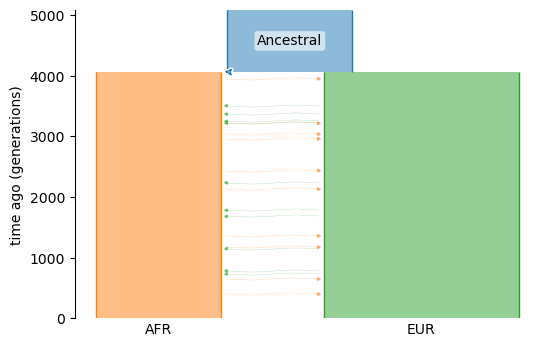

In [7]:
import matplotlib.pyplot as plt
import demes
import demesdraw

# Define the demographic model using a YAML string format (IM model)
yaml_model = f"""
description: Split with immediate symmetric migration
time_units: generations
demes:
  - name: Ancestral
    start_time: .inf
    epochs:
      - end_time: {T_split_gen:.2f}
        start_size: {N_a:.2f}

  - name: AFR
    start_time: {T_split_gen:.2f}
    ancestors: [Ancestral]
    epochs:
      - end_time: 0
        start_size: {nu_AFR:.2f}

  - name: EUR
    start_time: {T_split_gen:.2f}
    ancestors: [Ancestral]
    epochs:
      - end_time: 0
        start_size: {nu_EUR:.2f}

migrations:
  - source: AFR
    dest: EUR
    start_time: {T_split_gen:.2f}
    end_time: 0
    rate: {m_per_gen:.9f}

  - source: EUR
    dest: AFR
    start_time: {T_split_gen:.2f}
    end_time: 0
    rate: {m_per_gen:.9f}
"""

# Load the YAML model into a demes graph object
graph = demes.loads(yaml_model)

# Visualize the model
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
demesdraw.tubes(graph, ax=ax)
plt.show()


In [8]:
# Make a wrapper that fixes M (dadi-scaled migration) and only optimizes ν1, ν2, T
def model_with_fixed_M(params_free, ns, pts, M_fixed):
    nu1, nu2, T = params_free
    return split_mig_model([nu1, nu2, T, M_fixed], ns, pts)

func_fixed = lambda params_free, ns, pts, M: dadi.Numerics.make_extrap_log_func(
    lambda pf, ns, pts: model_with_fixed_M(pf, ns, pts, M)
)

def ll_at_M(M_fixed, p0_free):
    f = func_fixed(p0_free, ns, pts_l, M_fixed)
    popt_free = dadi.Inference.optimize_log(
        p0_free, fs, f, pts_l,
        lower_bound=[1e-3, 1e-3, 1e-4],
        upper_bound=[100, 100, 10.0]
    )
    mdl = f(popt_free, ns, pts_l)
    return dadi.Inference.ll_multinom(mdl, fs), popt_free

# Grid across M (dadi scale). Start around your M ≈ 0.798; explore ×(1/10 .. ×10)
M_grid = np.geomspace(0.08, 8.0, 25)
lls = []
for Mfix in M_grid:
    ll, pf = ll_at_M(Mfix, [best_popt[0], best_popt[1], best_popt[2]])
    lls.append((Mfix, ll, pf))



=== Migration likelihood profile (refitting ν1, ν2, T at each fixed M) ===
 M_fixed_dadi  logL_multinom  nu_AFR_hat  nu_EUR_hat    T_hat   m_per_gen
         0.08       -3446.28     1.01458     1.64029 0.110139  2.6882e-06
    0.0969222       -3440.61     1.01491      1.6395 0.110768 3.25682e-06
     0.117424       -3433.89     1.01558     1.63844 0.111499 3.94573e-06
     0.142262       -3425.97     1.01618     1.63708 0.112412 4.78036e-06
     0.172355        -3416.7      1.0167      1.6356 0.113511 5.79154e-06
     0.208813       -3406.08     1.01836     1.63271 0.114821 7.01661e-06
     0.252982       -3394.21     1.01834     1.62998 0.116535 8.50082e-06
     0.306495       -3381.84     1.01718     1.62286  0.11815  1.0299e-05
     0.371327       -3368.04     1.01788     1.61693 0.120581 1.24775e-05
     0.449873       -3353.54      1.0167      1.6078 0.123383 1.51168e-05
     0.545034       -3339.55     1.01473     1.59636 0.126892 1.83145e-05
     0.660323       -3328.29     1.0

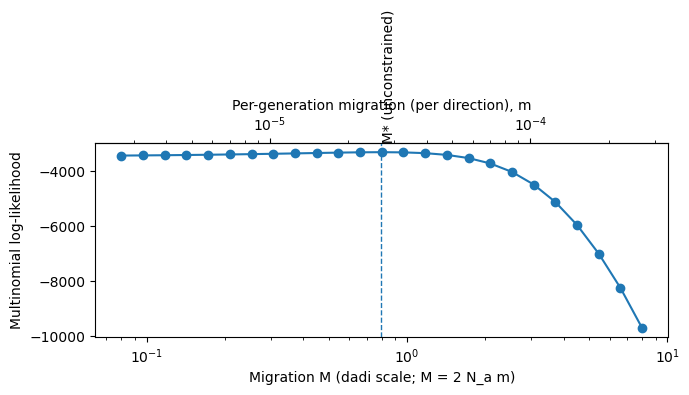

In [9]:
# --- Likelihood profile & plot for migration (add this right after your loop) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If N_a isn't already defined above, derive it (needs mu, L, func, fs, pts_l, best_popt)
try:
    N_a  # noqa: F823
except NameError:
    model_fs_ = func(best_popt, ns, pts_l)
    theta_ = dadi.Inference.optimal_sfs_scaling(model_fs_, fs)
    N_a = theta_ / (4 * mu * L)

# Extract unconstrained M* from your best fit
M_star = float(best_popt[3])

# Reuse the results you already computed
M_vals  = np.array([r[0] for r in lls], dtype=float)
LL_vals = np.array([r[1] for r in lls], dtype=float)
PF_vals = [r[2] for r in lls]  # refit [nu1, nu2, T] for each fixed M

# Make a tidy dataframe for inspection/saving
profile_df = pd.DataFrame({
    "M_fixed_dadi": M_vals,
    "logL_multinom": LL_vals,
    "nu_AFR_hat": [pf[0] for pf in PF_vals],
    "nu_EUR_hat": [pf[1] for pf in PF_vals],
    "T_hat":       [pf[2] for pf in PF_vals],
})
profile_df["m_per_gen"] = profile_df["M_fixed_dadi"] / (2.0 * N_a)
profile_df = profile_df.sort_values("M_fixed_dadi").reset_index(drop=True)
print("\n=== Migration likelihood profile (refitting ν1, ν2, T at each fixed M) ===")
print(profile_df.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

# Plot log-likelihood vs M (dadi scale), with a top axis in m_per_gen
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(profile_df["M_fixed_dadi"], profile_df["logL_multinom"], marker="o")
ax.set_xscale("log")
ax.set_xlabel("Migration M (dadi scale; M = 2 N_a m)")
ax.set_ylabel("Multinomial log-likelihood")

# Mark the unconstrained optimum M*
ax.axvline(M_star, linestyle="--", linewidth=1)
ax.text(M_star, np.max(profile_df["logL_multinom"]),
        "  M* (unconstrained)", rotation=90, va="bottom", ha="left")

# Add secondary x-axis in per-generation per-direction units
def M_to_m(M): return M / (2.0 * N_a)
def m_to_M(m): return m * (2.0 * N_a)
secax = ax.secondary_xaxis("top", functions=(M_to_m, m_to_M))
secax.set_xlabel("Per-generation migration (per direction), m")

# Optional: also show ΔlogL from the maximum (uncomment to annotate)
# dLL = profile_df["logL_multinom"] - profile_df["logL_multinom"].max()
# for Mv, d in zip(profile_df["M_fixed_dadi"], dLL):
#     ax.annotate(f"ΔLL={d:.2f}", xy=(Mv, profile_df.loc[profile_df['M_fixed_dadi']==Mv, 'logL_multinom'].values[0]),
#                 xytext=(0,5), textcoords="offset points", rotation=90, ha="center", fontsize=8)

plt.tight_layout()
plt.show()
# --- end profile plot ---


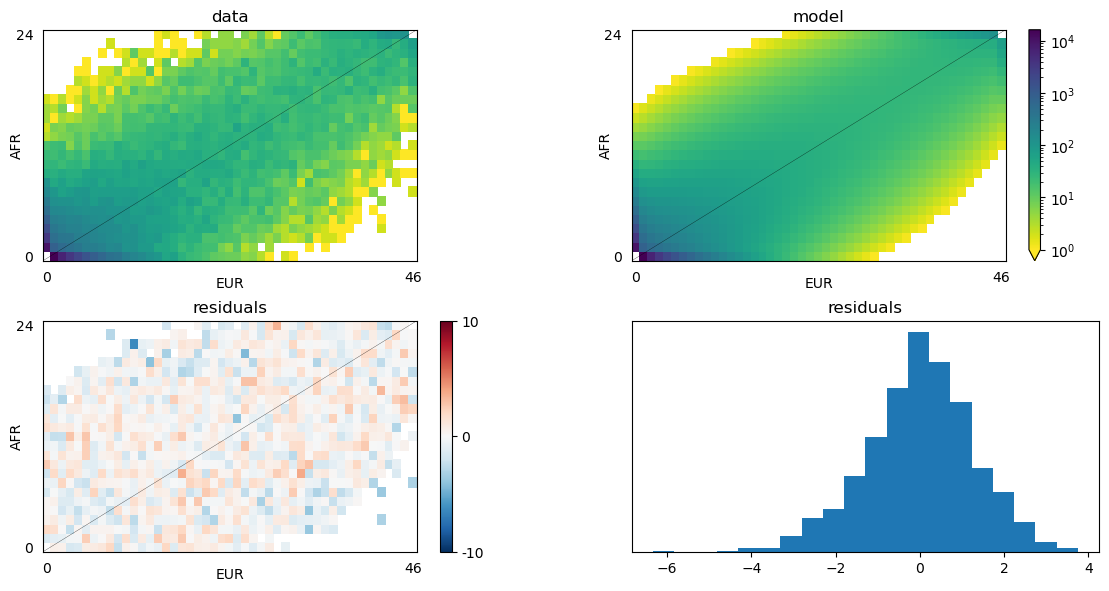

In [35]:
import dadi
import matplotlib.pyplot as plt

# Assuming `fs` is your observed frequency spectrum from the real data
# Assuming `popt` are the optimized parameters from the inferred model

# 1. Generate the model frequency spectrum using the optimized parameters
# Your demographic model function should be already defined (e.g., split_no_mig_model)
model = func(popt, fs.sample_sizes, pts_l)

# 2. Plot the comparison between the observed and model frequency spectrum
fig = plt.figure(figsize=(12, 6))

# Use dadi's plotting function to compare the observed and model FS
dadi.Plotting.plot_2d_comp_multinom(model, fs, vmin=1, resid_range=10)

plt.show()

In [11]:
import numpy as np
import dadi
from math import log

# --- 4p baseline (already defined elsewhere) ---
# def split_mig_model(params, ns, pts):
#     nu_AFR, nu_EUR, T, m = params
#     ...

# ---------- 5p: EUR growth ----------
def split_IM_EURgrowth(params, ns, pts):
    # params: [nu_AFR, nu_EUR0, nu_EURF, T, m]
    nu_AFR, nu_EUR0, nu_EURF, T, m = params

    xx  = dadi.Numerics.default_grid(pts)
    phi = dadi.PhiManip.phi_1D(xx)
    phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

    # exponential growth in EUR from nu_EUR0 at split to nu_EURF at present
    nu_EUR = lambda t: nu_EUR0 * (nu_EURF / nu_EUR0) ** (t / max(T, 1e-12))
    nu_AFR_const = lambda t: nu_AFR

    phi = dadi.Integration.two_pops(
        phi, xx, T,
        nu1=nu_AFR_const,   # AFR constant
        nu2=nu_EUR,         # EUR exponential growth
        m12=m, m21=m
    )
    return dadi.Spectrum.from_phi(phi, ns, (xx, xx))  # corners masked by default

# ---------- 5p: AFR growth ----------
def split_IM_AFRgrowth(params, ns, pts):
    # params: [nu_AFR0, nu_AFRF, nu_EUR, T, m]
    nu_AFR0, nu_AFRF, nu_EUR, T, m = params

    xx  = dadi.Numerics.default_grid(pts)
    phi = dadi.PhiManip.phi_1D(xx)
    phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

    # exponential growth in AFR from nu_AFR0 at split to nu_AFRF at present
    nu_AFR = lambda t: nu_AFR0 * (nu_AFRF / nu_AFR0) ** (t / max(T, 1e-12))
    nu_EUR_const = lambda t: nu_EUR

    phi = dadi.Integration.two_pops(
        phi, xx, T,
        nu1=nu_AFR,         # AFR exponential growth
        nu2=nu_EUR_const,   # EUR constant
        m12=m, m21=m
    )
    return dadi.Spectrum.from_phi(phi, ns, (xx, xx))

# ---- Extrapolated wrappers ----
func0 = dadi.Numerics.make_extrap_log_func(split_mig_model)       # 4p IM
func1 = dadi.Numerics.make_extrap_log_func(split_IM_EURgrowth)    # 5p IM + EUR growth
func2 = dadi.Numerics.make_extrap_log_func(split_IM_AFRgrowth)    # 5p IM + AFR growth

# ---- Seeds and bounds ----
nu_AFR0, nu_EUR0, T0, m0 = best_popt

# EUR growth seed: start smaller, end larger than constant solution
p0_eur = [nu_AFR0, nu_EUR0 * 0.7, nu_EUR0 * 1.8, T0, m0]
# AFR growth seed: start smaller, end larger than constant solution
p0_afr = [nu_AFR0 * 0.7, nu_AFR0 * 1.8, nu_EUR0, T0, m0]

# bounds (tweak if you have prior knowledge)
lower0 = [1e-3, 1e-3, 1e-4, 0.0]            # 4p
upper0 = [  50,   50,  10.0, 5.0]

lower1 = [1e-3, 1e-3, 1e-3, 1e-4, 0.0]      # 5p EUR growth
upper1 = [  50,   50,  200,  10.0, 5.0]

lower2 = [1e-3, 1e-3, 1e-3, 1e-4, 0.0]      # 5p AFR growth
upper2 = [ 200,   50,   50,  10.0, 5.0]

# ---- Fit all three ----
popt0 = dadi.Inference.optimize_log(best_popt, fs, func0, pts_l,
                                    lower_bound=lower0, upper_bound=upper0, verbose=1)

popt1 = dadi.Inference.optimize_log(p0_eur,    fs, func1, pts_l,
                                    lower_bound=lower1, upper_bound=upper1, verbose=1)

popt2 = dadi.Inference.optimize_log(p0_afr,    fs, func2, pts_l,
                                    lower_bound=lower2, upper_bound=upper2, verbose=1)

# ---- Log-likelihoods ----
ll0 = dadi.Inference.ll_multinom(func0(popt0, ns, pts_l), fs)
ll1 = dadi.Inference.ll_multinom(func1(popt1, ns, pts_l), fs)
ll2 = dadi.Inference.ll_multinom(func2(popt2, ns, pts_l), fs)

# ---- AIC ----
k0, k1, k2 = 4, 5, 5
AIC0 = 2*k0 - 2*ll0
AIC1 = 2*k1 - 2*ll1
AIC2 = 2*k2 - 2*ll2

# ---- Pretty summaries ----
def rate_and_fold(nu0, nuF, T):
    fold = nuF / nu0
    r = np.nan if T <= 1e-12 else log(fold) / T   # exponential rate per (2*Nref gens)
    return fold, r

print("\n=== Parameter summaries (scaled units) ===")
print(f"[IM 4p]     nu_AFR={popt0[0]:.3g}, nu_EUR={popt0[1]:.3g}, T={popt0[2]:.3g}, m={popt0[3]:.3g}")

foldE, rE = rate_and_fold(popt1[1], popt1[2], popt1[3])
print(f"[IM+EUR g]  nu_AFR={popt1[0]:.3g}, nu_EUR0={popt1[1]:.3g}, nu_EURF={popt1[2]:.3g}, "
      f"T={popt1[3]:.3g}, m={popt1[4]:.3g}, fold_EUR={foldE:.3f}, r_EUR={rE:.3e}")

foldA, rA = rate_and_fold(popt2[0], popt2[1], popt2[3])
print(f"[IM+AFR g]  nu_AFR0={popt2[0]:.3g}, nu_AFRF={popt2[1]:.3g}, nu_EUR={popt2[2]:.3g}, "
      f"T={popt2[3]:.3g}, m={popt2[4]:.3g}, fold_AFR={foldA:.3f}, r_AFR={rA:.3e}")

# ---- Model comparison table ----
results = [
    ("IM 4p",     k0, ll0, AIC0, popt0),
    ("IM+EUR g",  k1, ll1, AIC1, popt1),
    ("IM+AFR g",  k2, ll2, AIC2, popt2),
]
best_AIC = min(r[3] for r in results)

print("\n=== Model comparison (lower AIC is better) ===")
for name, k, ll, aic, _ in sorted(results, key=lambda x: x[3]):
    print(f"{name:9s} | k={k} | LL={ll:9.2f} | AIC={aic:9.2f} | ΔAIC={aic - best_AIC:6.2f}")

# Quick rule of thumb:
print("\nΔAIC ~ 0–2: essentially equivalent; 4–10: some support; >10: strong support for the lower-AIC model.")


1402    , -3323.42    , array([ 1.00465    ,  1.56161    ,  0.136571   ,  0.798143   ])


1403    , -3323.42    , array([ 1.00565    ,  1.56161    ,  0.136571   ,  0.798143   ])
1404    , -3323.42    , array([ 1.00465    ,  1.56318    ,  0.136571   ,  0.798143   ])
1405    , -3323.42    , array([ 1.00465    ,  1.56161    ,  0.136707   ,  0.798143   ])
1406    , -3323.42    , array([ 1.00465    ,  1.56161    ,  0.136571   ,  0.798941   ])
1407    , -13595.9    , array([ 1.70791    ,  2.16563    ,  0.0639429  ,  1.01069    ])
1408    , -13604.6    , array([ 1.70962    ,  2.16563    ,  0.0639429  ,  1.01069    ])
1409    , -13602.9    , array([ 1.70791    ,  2.1678     ,  0.0639429  ,  1.01069    ])
1410    , -13581.9    , array([ 1.70791    ,  2.16563    ,  0.0640069  ,  1.01069    ])
1411    , -13597.9    , array([ 1.70791    ,  2.16563    ,  0.0639429  ,  1.01171    ])
1412    , -3323.42    , array([ 1.00472    ,  1.56168    ,  0.136557   ,  0.798169   ])
1413    , -3323.42    , array([ 1.00573    ,  1.56168    ,  0.136557   ,  0.798169   ])
1414    , -3323.42    , array([ 


=== Model fit summary ===
IM 4p     : LL=-3323.42, AIC=6654.84
IM+EUR gr : LL=-3322.13, AIC=6654.27,  LRT vs IM: 2ΔLL=2.58, p≈0.109
IM+AFR gr : LL=-3321.66, AIC=6653.33,  LRT vs IM: 2ΔLL=3.51, p≈0.061

Best (by AIC): IM+AFR g

=== Interpretable parameters ===
[IM 4p] θ=12898.20, N_a=14,880.08
       N_AFR=14,950.33, N_EUR=23,238.00
       Split: 4,063.94 generations (~4,063.94 years)
       m per gen (both directions): 2.682e-05
[IM+EUR growth] θ=12877.19, N_a=14,855.84
       N_AFR (const)=14,960.73
       N_EUR at split=25,850.86 → present=22,065.37  (fold=0.854)
       Split: 4,073.17 generations (~4,073.17 years)
       m per gen: 2.6555e-05
       Exponential rate r_EUR per (2*N_a) gens: -1.155e+00
[IM+AFR growth] θ=12924.94, N_a=14,910.92
       N_AFR at split=13,085.25 → present=16,261.54  (fold=1.243)
       N_EUR (const)=23,268.93
       Split: 4,025.31 generations (~4,025.31 years)
       m per gen: 2.65456e-05
       Exponential rate r_AFR per (2*N_a) gens: 1.610e+00


AttributeError: module 'dadi.Inference' has no attribute 'residuals'

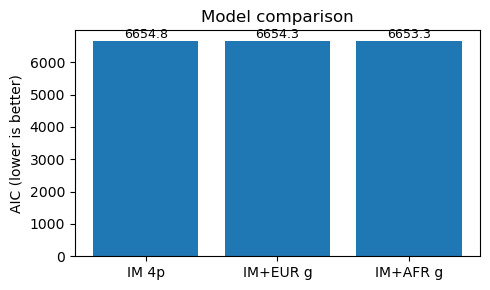

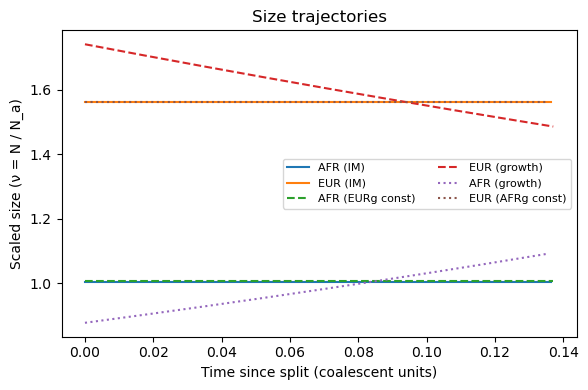

In [12]:
# ==== Interpretation + Plots for IM, EUR growth, AFR growth ====
import numpy as np
import matplotlib.pyplot as plt
import dadi
from math import log
from scipy.stats import chi2

# ---- User inputs (make sure these are set) ----
mu = 1e-8                          # mut rate per bp per generation
L = REGION_LENGTH                  # callable region length (bp)
generation_time = 1                # years/gen

# ---- Convenience: wrappers that should already exist from your run ----
# func0 = dadi.Numerics.make_extrap_log_func(split_mig_model)        # 4p: [nu_AFR, nu_EUR, T, m]
# func1 = dadi.Numerics.make_extrap_log_func(split_IM_EURgrowth)     # 5p: [nu_AFR, nu_EUR0, nu_EURF, T, m]
# func2 = dadi.Numerics.make_extrap_log_func(split_IM_AFRgrowth)     # 5p: [nu_AFR0, nu_AFRF, nu_EUR, T, m]
# popt0, popt1, popt2 available from your last optimization

# ---------- Utilities ----------
def theta_and_Na(model_func, params):
    """Return (theta, N_a) for a model and its params."""
    mfs = model_func(params, ns, pts_l)
    theta = dadi.Inference.optimal_sfs_scaling(mfs, fs)
    Na = theta / (4 * mu * L)
    return theta, Na, mfs

def m_per_gen(m_scaled, Na):
    # dadi’s m is 2*Na*m_per_gen
    return m_scaled / (2 * Na)

def t_to_gen_years(T, Na):
    gens = T * 2 * Na
    yrs = gens * generation_time
    return gens, yrs

def exp_curve(nu0, nuF, T, npts=200):
    """Return t in [0,T] and nu(t) for exponential change."""
    t = np.linspace(0, T, npts)
    with np.errstate(divide="ignore", invalid="ignore"):
        nu = nu0 * (nuF/nu0) ** (np.where(T>0, t/T, 0.0))
    return t, nu

def residuals(data_fs, model_fs):
    # multinomial residuals like dadi's plotting
    return dadi.Inference.optimal_sfs_scaling(model_fs, data_fs), (data_fs - model_fs)

# ---------- Log-likelihoods and AIC from your fit ----------
ll0 = dadi.Inference.ll_multinom(func0(popt0, ns, pts_l), fs)  # 4p
ll1 = dadi.Inference.ll_multinom(func1(popt1, ns, pts_l), fs)  # EUR growth
ll2 = dadi.Inference.ll_multinom(func2(popt2, ns, pts_l), fs)  # AFR growth

k0, k1, k2 = 4, 5, 5
AIC0 = 2*k0 - 2*ll0
AIC1 = 2*k1 - 2*ll1
AIC2 = 2*k2 - 2*ll2

# LRTs vs baseline (df=1)
deltaLL_afr = 2*(ll2 - ll0)
deltaLL_eur = 2*(ll1 - ll0)
p_afr = 1 - chi2.cdf(deltaLL_afr, 1)
p_eur = 1 - chi2.cdf(deltaLL_eur, 1)

# ---------- Translate params to interpretable units for all models ----------
out = {}

# 4p IM
theta0, Na0, mfs0 = theta_and_Na(func0, popt0)
nu_AFR0, nu_EUR0, T0, m0 = popt0
N_AFR0 = nu_AFR0 * Na0
N_EUR0 = nu_EUR0 * Na0
T0_g, T0_y = t_to_gen_years(T0, Na0)
m0_pg = m_per_gen(m0, Na0)
out["IM 4p"] = dict(
    theta=theta0, Na=Na0, T=T0, T_gen=T0_g, T_years=T0_y,
    N_AFR=N_AFR0, N_EUR=N_EUR0, m_per_gen=m0_pg, params=popt0, mfs=mfs0
)

# 5p EUR growth
theta1, Na1, mfs1 = theta_and_Na(func1, popt1)
nu_AFR1, nu_EUR0_1, nu_EURF_1, T1, m1 = popt1
N_AFR1 = nu_AFR1 * Na1
N_EUR0_1_abs = nu_EUR0_1 * Na1
N_EURF_1_abs = nu_EURF_1 * Na1
fold_EUR = nu_EURF_1 / nu_EUR0_1
r_EUR = (np.log(fold_EUR) / T1) if T1 > 0 else np.nan  # per (2*Na) gens
T1_g, T1_y = t_to_gen_years(T1, Na1)
m1_pg = m_per_gen(m1, Na1)
out["IM+EUR g"] = dict(
    theta=theta1, Na=Na1, T=T1, T_gen=T1_g, T_years=T1_y,
    N_AFR=N_AFR1, N_EUR0=N_EUR0_1_abs, N_EURF=N_EURF_1_abs,
    fold_EUR=fold_EUR, r_EUR=r_EUR, m_per_gen=m1_pg, params=popt1, mfs=mfs1
)

# 5p AFR growth
theta2, Na2, mfs2 = theta_and_Na(func2, popt2)
nu_AFR0_2, nu_AFRF_2, nu_EUR2, T2, m2 = popt2
N_AFR0_2_abs = nu_AFR0_2 * Na2
N_AFRF_2_abs = nu_AFRF_2 * Na2
N_EUR2 = nu_EUR2 * Na2
fold_AFR = nu_AFRF_2 / nu_AFR0_2
r_AFR = (np.log(fold_AFR) / T2) if T2 > 0 else np.nan
T2_g, T2_y = t_to_gen_years(T2, Na2)
m2_pg = m_per_gen(m2, Na2)
out["IM+AFR g"] = dict(
    theta=theta2, Na=Na2, T=T2, T_gen=T2_g, T_years=T2_y,
    N_AFR0=N_AFR0_2_abs, N_AFRF=N_AFRF_2_abs, N_EUR=N_EUR2,
    fold_AFR=fold_AFR, r_AFR=r_AFR, m_per_gen=m2_pg, params=popt2, mfs=mfs2
)

# ---------- Print human-readable summaries ----------
def fmt(n): 
    return f"{n:,.2f}"

print("\n=== Model fit summary ===")
print(f"IM 4p     : LL={ll0:.2f}, AIC={AIC0:.2f}")
print(f"IM+EUR gr : LL={ll1:.2f}, AIC={AIC1:.2f},  LRT vs IM: 2ΔLL={deltaLL_eur:.2f}, p≈{p_eur:.3f}")
print(f"IM+AFR gr : LL={ll2:.2f}, AIC={AIC2:.2f},  LRT vs IM: 2ΔLL={deltaLL_afr:.2f}, p≈{p_afr:.3f}")

best_name = min([("IM 4p",AIC0), ("IM+EUR g",AIC1), ("IM+AFR g",AIC2)], key=lambda x:x[1])[0]
print(f"\nBest (by AIC): {best_name}")

print("\n=== Interpretable parameters ===")
# IM 4p
o = out["IM 4p"]
print(f"[IM 4p] θ={o['theta']:.2f}, N_a={fmt(o['Na'])}")
print(f"       N_AFR={fmt(o['N_AFR'])}, N_EUR={fmt(o['N_EUR'])}")
print(f"       Split: {fmt(o['T_gen'])} generations (~{fmt(o['T_years'])} years)")
print(f"       m per gen (both directions): {o['m_per_gen']:.6g}")

# IM+EUR g
o = out["IM+EUR g"]
print(f"[IM+EUR growth] θ={o['theta']:.2f}, N_a={fmt(o['Na'])}")
print(f"       N_AFR (const)={fmt(o['N_AFR'])}")
print(f"       N_EUR at split={fmt(o['N_EUR0'])} → present={fmt(o['N_EURF'])}  (fold={o['fold_EUR']:.3f})")
print(f"       Split: {fmt(o['T_gen'])} generations (~{fmt(o['T_years'])} years)")
print(f"       m per gen: {o['m_per_gen']:.6g}")
print(f"       Exponential rate r_EUR per (2*N_a) gens: {o['r_EUR']:.3e}")

# IM+AFR g
o = out["IM+AFR g"]
print(f"[IM+AFR growth] θ={o['theta']:.2f}, N_a={fmt(o['Na'])}")
print(f"       N_AFR at split={fmt(o['N_AFR0'])} → present={fmt(o['N_AFRF'])}  (fold={o['fold_AFR']:.3f})")
print(f"       N_EUR (const)={fmt(o['N_EUR'])}")
print(f"       Split: {fmt(o['T_gen'])} generations (~{fmt(o['T_years'])} years)")
print(f"       m per gen: {o['m_per_gen']:.6g}")
print(f"       Exponential rate r_AFR per (2*N_a) gens: {o['r_AFR']:.3e}")

# ---------- Plots ----------
# 1) AIC bar plot
fig, ax = plt.subplots(1,1,figsize=(5,3))
models = ["IM 4p","IM+EUR g","IM+AFR g"]
aics   = [AIC0, AIC1, AIC2]
bars = ax.bar(models, aics)
ax.set_ylabel("AIC (lower is better)")
ax.set_title("Model comparison")
for b,v in zip(bars,aics):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()

# 2) Growth curves (nu(t) in coalescent units; annotate absolute N where helpful)
fig, ax = plt.subplots(1,1,figsize=(6,4))
# IM 4p: constant lines
o = out["IM 4p"]
t = np.linspace(0, o["T"], 200)
ax.plot(t, np.full_like(t, popt0[0]), label="AFR (IM)")
ax.plot(t, np.full_like(t, popt0[1]), label="EUR (IM)")

# EUR growth
o = out["IM+EUR g"]
tE, nuE = exp_curve(popt1[1], popt1[2], popt1[3])
ax.plot(tE, popt1[0]*np.ones_like(tE), linestyle="--", label="AFR (EURg const)")
ax.plot(tE, nuE, linestyle="--", label="EUR (growth)")

# AFR growth
o = out["IM+AFR g"]
tA, nuA = exp_curve(popt2[0], popt2[1], popt2[3])
ax.plot(tA, nuA, linestyle=":", label="AFR (growth)")
ax.plot(tA, popt2[2]*np.ones_like(tA), linestyle=":", label="EUR (AFRg const)")

ax.set_xlabel("Time since split (coalescent units)")
ax.set_ylabel("Scaled size (ν = N / N_a)")
ax.legend(ncols=2, fontsize=8)
ax.set_title("Size trajectories")
plt.tight_layout()

# 3) SFS residuals for each model
def plot_residual_panel(data_fs, model_fs, title, vmax=None):
    resid = dadi.Inference.residuals(model_fs, data_fs, mask=True)  # standardized residuals
    fig, axes = plt.subplots(1,3,figsize=(12,3))
    dadi.Plotting.plot_single_2d_sfs(model_fs, vmin=1, vmax=vmax, ax=axes[0])
    axes[0].set_title(f"{title}: model SFS")
    dadi.Plotting.plot_2d_residual(resid, ax=axes[1], residual='Anscombe')
    axes[1].set_title(f"{title}: residuals (heatmap)")
    axes[2].hist(resid.compressed(), bins=30)
    axes[2].set_title(f"{title}: residuals (hist)")
    plt.tight_layout()
    return fig

_ = plot_residual_panel(fs, out["IM 4p"]["mfs"],   "IM 4p")
_ = plot_residual_panel(fs, out["IM+EUR g"]["mfs"],"IM+EUR growth")
_ = plot_residual_panel(fs, out["IM+AFR g"]["mfs"],"IM+AFR growth")

plt.show()
